##  Identify barcode lineage with pre-existing mutations, for use in Figs. 5, 7, and S6


In [28]:
import sys; sys.path.insert(0, '../../');
from methods.config import *
import numpy as np; rnd=np.random.default_rng()
import matplotlib.pyplot as plt
import matplotlib as mpl
import methods.util as util
import pickle
import methods.shared as shared

import statsmodels.api as sm
from scipy.stats import kstest, ttest_ind, ttest_rel

## Fig. S6A: Cross-environment in vivo fitness

This code identifies barcodes with pre-existing variation, identified as consistently expanding over the short term (first ~week) across independent mice/cages


In [7]:
def find_init_freq_matched_control(init_freqs, null_freqs, null_indices):
    sort_null = np.argsort(null_freqs)[::-1]
    sorted_null_freqs = np.ma.masked_array(null_freqs[sort_null])
    sorted_null_indices = np.ma.masked_array(null_indices[sort_null])

    sorted_null_freqs[sorted_null_freqs == 0] = 1e-100 # to track lineages already included in null set

    matched_indices = []
    subset_freqs = []
    for freq in init_freqs:
        if freq == 0:
            matched_indices.append(-1)
            continue

        else:
            delta = np.abs(np.log(sorted_null_freqs/freq))
            z = np.argmin( delta )
            subset_freqs.append(sorted_null_freqs[z])
            matched_indices.append( sorted_null_indices[z] )
            sorted_null_freqs[z] = 1e-100
    return np.array(matched_indices, dtype=int)

Num. filtered barcodes in S1: 1653
    	Correlations between log-init frequency and fitness:
    	E1: -0.16873548309482947
    	E2: 0.027886988793087708
Num. filtered barcodes in S2: 1254
    	Correlations between log-init frequency and fitness:
    	E1: -0.08353956435897716
    	E2: 0.09518513504403966
Num. SD-mono high-fitness barcodes in inocula 1 and 2 (tot): 426 302 (728)
 Num. filtered barcodes in MD: 727
    	Correlations between log-init frequency and fitness:
    	SD-fit bc: -0.08037253128218044
    	Null: -0.009809689630428014
 Num. filtered barcodes in comm: 407
    	Correlations between log-init frequency and fitness:
    	SD-fit bc: -0.41554433002187524
    	Null: -0.4092184912546727
 Num. filtered barcodes in comm: 296
    	Correlations between log-init frequency and fitness:
    	SD-fit bc: -0.16563476340649502
    	Null: -0.01914212207979526
 Num. filtered barcodes in delay: 408
    	Correlations between log-init frequency and fitness:
    	SD-fit bc: 0.0801787215879225

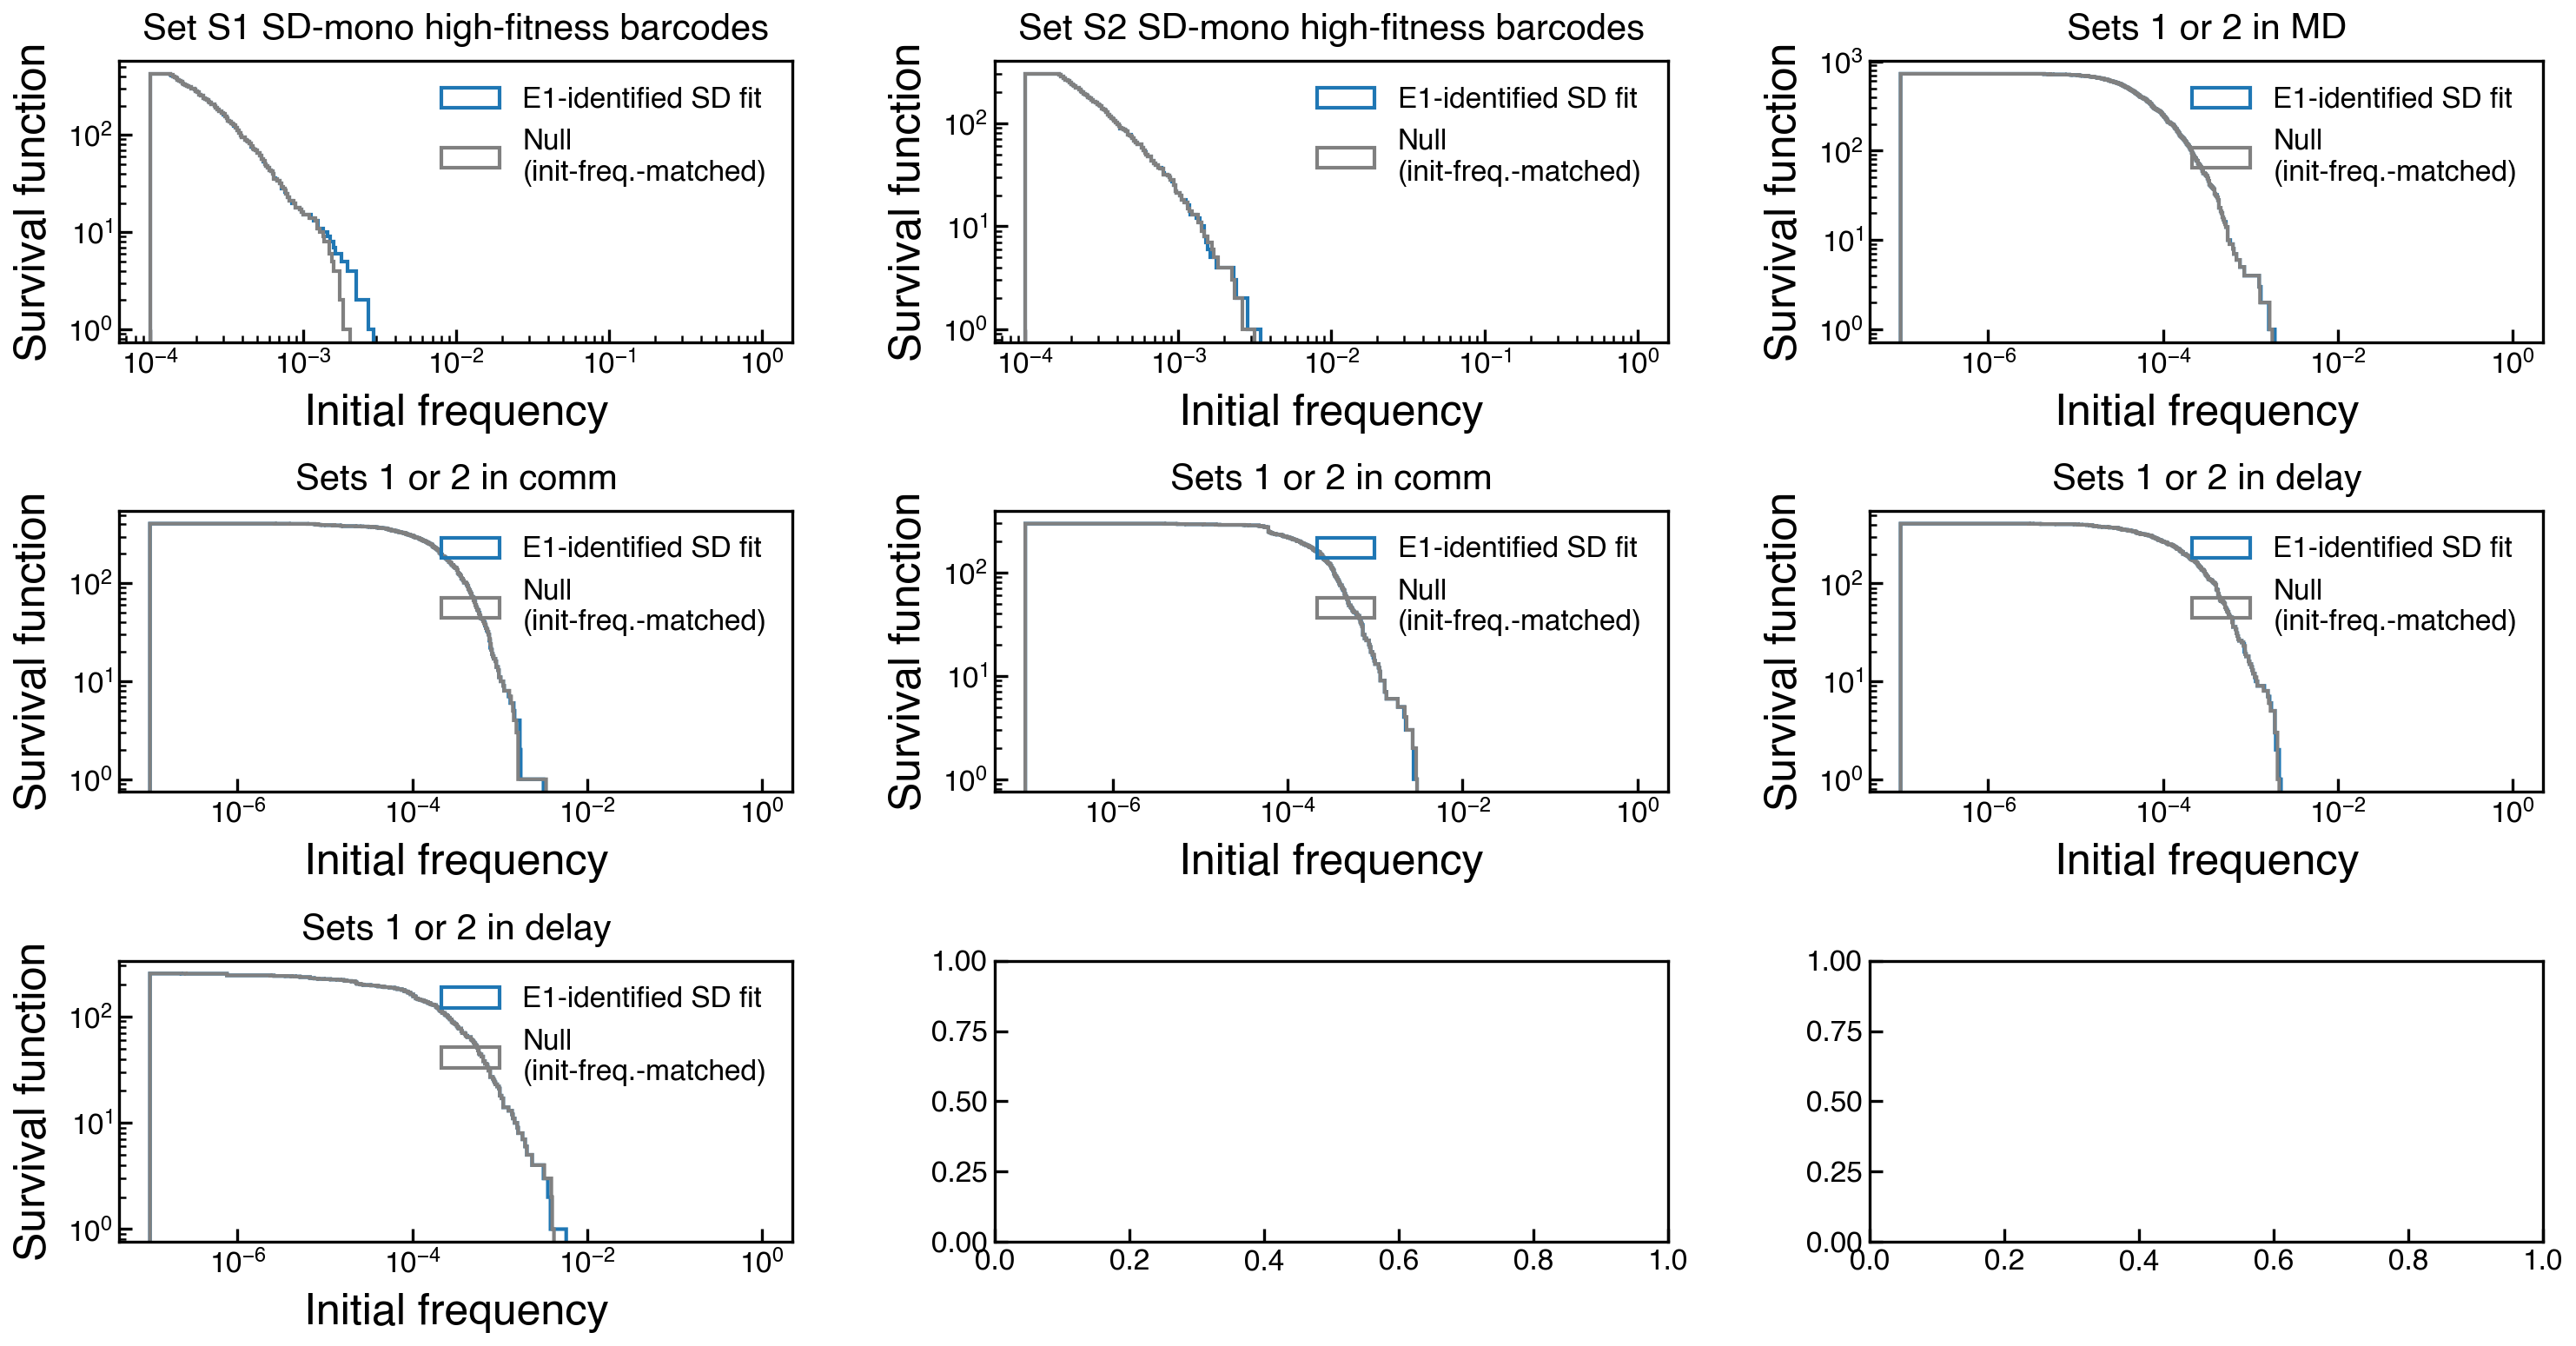

In [38]:
invivo_fitness_dict = {'barcodes':[], 
                       'all_null_indices':[], 
                       'barcode_indices':[], 
                       'SD1':[], 'SD2':[], 'SD2_null':[]}## SD1 = E1, SD2 = E2
all_indices = np.arange(shared.barcodes.shape[-1])

SD1_m, SD1_t1, SD1_t2 = 6, 2, 9
SD2_m, SD2_t1, SD2_t2 = 7, 3, 8 ## these t1, t2 differ due to different sampled timepoints
SD_MIN_FC = 1
MD_t1, MD_t2 = 2, 9
comm_t1, comm_t2 = 3, 8 # comm_t2 = 7 for set2
delay_t1, delay_t2 = 16, 25

SD1_f1, SD1_D1 = shared.cage_avg_freqs('E1', [6, 7, 8, 9, 10], SD1_t1)
SD1_f2, SD1_D2 = shared.cage_avg_freqs('E1', [6, 7, 8, 9, 10], SD1_t2)
SD1_f1, SD1_f2 = shared.maxmin_freqs(SD1_f1, SD1_D1, SD1_f2, SD1_D2)

fig, axs = plt.subplots(3, 3, figsize=(12, 6), dpi=300, gridspec_kw={'hspace':0.6, 'wspace':0.3})
for z, (bc_set, SD2_m) in enumerate(zip(['S1', 'S2'], [6, 7])):
    SD2_f1, SD2_D1 = shared.cage_avg_freqs('E2', [SD2_m], SD2_t1)
    SD2_f2, SD2_D2 = shared.cage_avg_freqs('E2', [SD2_m], SD2_t2)
    SD2_f1, SD2_f2 = shared.maxmin_freqs(SD2_f1, SD2_D1, SD2_f2, SD2_D2)

    # conditioning (substantial initial frequency in both inocula, and positive fold-change in Experiment 1 / E1)
    cutoff_SD1, cutoff_SD2, = 20/SD1_D1, 20/SD2_D1
    valid = (SD1_f1 > cutoff_SD1) & (SD2_f1 > cutoff_SD2) & (shared.barcode_pool_assignments['P1'][1]) & (shared.barcode_pool_assignments[bc_set][1]) 
    SD1_fc = (SD1_f2[valid] / SD1_f1[valid])
    SD2_fc = (SD2_f2[valid] / SD2_f1[valid])
    conditional_adaptive = (SD1_fc > SD_MIN_FC) 
    indices = np.arange(shared.barcodes.shape[0])[valid][conditional_adaptive]

    # calculating fitnesses
    SD1_fitness = np.log(SD1_fc)[conditional_adaptive] / (SD1_t2-SD1_t1)
    SD2_fitness = np.log(SD2_f2[valid][conditional_adaptive] / SD2_f1[valid][conditional_adaptive]) / (SD2_t2-SD2_t1)
    invivo_fitness_dict['barcodes'].extend( list(shared.barcodes[indices]) )
    invivo_fitness_dict['barcode_indices'].extend( list(indices) )
    invivo_fitness_dict['SD1'].extend( list(SD1_fitness) )
    invivo_fitness_dict['SD2'].extend( list(SD2_fitness) )
    invivo_fitness_dict[f'{bc_set}_barcodes'] = shared.barcodes[indices]
    invivo_fitness_dict[f'{bc_set}_indices'] = indices

    ### calculating null fitnesses for SD2 (E2) barcodes, matched by initial frequency
    fit_indices = invivo_fitness_dict[f'{bc_set}_indices']
    null_indices = np.array([idx for idx in all_indices if idx not in invivo_fitness_dict['barcode_indices']])
    SD2_null_freqs = SD2_f1[null_indices]
    SD2_null = find_init_freq_matched_control(SD2_f1[fit_indices], SD2_null_freqs, null_indices)

    SD2_f1, SD2_f2 = shared.maxmin_freqs(SD2_f1, SD2_D1, SD2_f2, SD2_D2)
    SD2_null_fitness = np.log(SD2_f2[SD2_null] / SD2_f1[SD2_null]) / (SD2_t2-SD2_t1)
    SD2_null_fitness[SD2_null == -1] = np.nan
    invivo_fitness_dict['SD2_null'].extend( list(SD2_null_fitness) )

    binspace = np.logspace(-4, 0, 401)
    ax = axs[z//3, z%3]
    ax.hist( SD2_f1[fit_indices], histtype='step', bins=binspace, cumulative=-1, label='E1-identified SD fit')
    ax.hist( SD2_f1[SD2_null], histtype='step', bins=binspace, cumulative=-1, color='grey', label='Null\n(init-freq.-matched)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Initial frequency', fontsize=12)
    ax.set_ylabel('Survival function', fontsize=12)
    ax.set_title(f'Set {bc_set} SD-mono high-fitness barcodes', fontsize=10)
    ax.legend(loc=1, fontsize=8, frameon=False)

    print( 
    f"""Num. filtered barcodes in {bc_set}: {valid.sum()}
    \tCorrelations between log-init frequency and fitness:
    \tE1: {np.corrcoef( np.log10(SD1_f1[indices]), SD1_fitness )[0,1]}
    \tE2: {np.corrcoef( np.log10(SD2_f1[indices]), SD2_fitness )[0,1]}"""
    )

invivo_fitness_dict['barcodes'] = np.array( invivo_fitness_dict['barcodes'] )
invivo_fitness_dict['barcode_indices'] = np.array( invivo_fitness_dict['barcode_indices'] )
invivo_fitness_dict['SD1'] = np.array(invivo_fitness_dict['SD1'])
invivo_fitness_dict['SD2'] = np.array(invivo_fitness_dict['SD2'])
invivo_fitness_dict['SD2_null'] = np.array(invivo_fitness_dict['SD2_null'])
print( 'Num. SD-mono high-fitness barcodes in inocula 1 and 2 (tot):', len(invivo_fitness_dict['S1_indices']), len(invivo_fitness_dict['S2_indices']), 
      f'({len(set(invivo_fitness_dict["S1_indices"]).union(invivo_fitness_dict["S2_indices"]))})')

for env_label in ['MD', 'comm', 'delay']:
    invivo_fitness_dict[env_label] = []
    invivo_fitness_dict[f'{env_label}_null'] = []

for z, (env_label, expt, env_mice, (t1, t2), SD_fit_indices) in enumerate([
    ('MD', 'E1', [11, 12, 13], [MD_t1, MD_t2], invivo_fitness_dict['barcode_indices']),
    ('comm', 'E2', [1], [comm_t1,8], invivo_fitness_dict['S1_indices']),
    ('comm', 'E2', [2], [comm_t1,7], invivo_fitness_dict['S2_indices']),
    ('delay', 'E2', [11], [delay_t1, delay_t2], invivo_fitness_dict['S1_indices']),
    ('delay', 'E2', [12], [delay_t1, delay_t2], invivo_fitness_dict['S2_indices'])]):

    env_f1, env_D1 = shared.cage_avg_freqs(expt, env_mice, t1)
    env_f2, env_D2 = shared.cage_avg_freqs(expt, env_mice, t2)

    ## calculate LFC of SD-fit barcodes in new environment
    env_f1, env_f2 = shared.maxmin_freqs(env_f1, env_D1, env_f2, env_D2)
    with np.errstate(divide='ignore', invalid='ignore'):
        env_lfc = np.log(env_f2[SD_fit_indices] / env_f1[SD_fit_indices]) / (t2 - t1)
    valid = ~np.isnan(env_lfc)
    invivo_fitness_dict[env_label].extend( list(env_lfc) )

    ## calculate LFC of null barcodes in new environment, matched by initial frequency
    null_indices = np.array([idx for idx in all_indices if idx not in invivo_fitness_dict['barcode_indices']])
    env_null_freqs = env_f1[null_indices]
    env_null = find_init_freq_matched_control(env_f1[SD_fit_indices], env_null_freqs, null_indices)

    with np.errstate(divide='ignore', invalid='ignore'):
        env_null_fitness = np.log(env_f2[env_null] / env_f1[env_null]) / (t2-t1)
    env_null_fitness[env_null == -1] = np.nan ## keep same dimension as SD-fit barcodes, but set to nan if no null match was found
    null_valid = ~np.isnan(env_null_fitness)
    invivo_fitness_dict[f'{env_label}_null'].extend( list(env_null_fitness) )

    ax = axs[(z+2)//3, (z+2)%3]
    binspace = np.logspace(-7, 0, 701)
    ax.hist( env_f1[SD_fit_indices], histtype='step', bins=binspace, cumulative=-1, label='E1-identified SD fit')
    ax.hist( env_f1[env_null], histtype='step', bins=binspace, cumulative=-1, color='grey', label='Null\n(init-freq.-matched)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Initial frequency', fontsize=12)
    ax.set_ylabel('Survival function', fontsize=12)
    ax.set_title(f'Sets 1 or 2 in {env_label}', fontsize=10)
    ax.legend(loc=1, fontsize=8, frameon=False)
    
    print(
    f""" Num. filtered barcodes in {env_label}: {valid.sum()}
    \tCorrelations between log-init frequency and fitness:
    \tSD-fit bc: {np.corrcoef( np.log10(env_f1[SD_fit_indices][valid]), env_lfc[valid] )[0,1]}
    \tNull: {np.corrcoef( np.log10(env_f1[env_null][null_valid]), env_null_fitness[null_valid] )[0,1]}"""
    )


for env_label in ['MD', 'comm', 'delay']:
    invivo_fitness_dict[env_label] = np.array(invivo_fitness_dict[env_label])
    invivo_fitness_dict[f'{env_label}_null'] = np.array(invivo_fitness_dict[f'{env_label}_null'])

with open(f'{pickled_dir}/vivo_fitness_dict.pkl', 'wb') as f:
    pickle.dump(invivo_fitness_dict, f)

## Derived data for Figs. 7D–F: In vivo–in vitro null distributions and bootstraps
find lfcs (over passage 1 -> 5) of SD-fit barcodes in vitro experiments

In [37]:
def bootstrap_excess(vivo_lfc, null_lfc, n_bootstrap=1000):  
    ## bootstrap the excess number of barcodes with log-fold change (fitness) above 0, -1, and -2 in a new environment, relative to null barcodes
    fitness_deltas = []
    excess_above_m2 = []
    excess_above_m1 = []
    excess_above_0 = []

    sample_indices = np.arange( len(vivo_lfc) )
    for _ in range(n_bootstrap):
        perm = rnd.choice(sample_indices, len(sample_indices), replace=True)

        bootstrap_vivo = vivo_lfc[perm]
        bootstrap_null = null_lfc[perm]

        fitness_deltas.append( np.mean(bootstrap_vivo) - np.mean(bootstrap_null) )
        excess_above_0.append( (bootstrap_vivo >0).sum() - (bootstrap_null>0).sum())
        excess_above_m1.append( (bootstrap_vivo >-1).sum() - (bootstrap_null>-1).sum())
        excess_above_m2.append( (bootstrap_vivo >-2).sum() - (bootstrap_null>-2).sum())

    return fitness_deltas, excess_above_0, excess_above_m1, excess_above_m2

vivo_fitnesses = invivo_fitness_dict['SD1']
vivo_indices = invivo_fitness_dict['barcode_indices']

ordered_media = shared.ordered_media
medium_vivo_null_distributions = {medium:[] for medium in ordered_media}
bootstrapped_data = {medium:{} for medium in ordered_media}
vitro_t1, vitro_t2 = 1, 5

for m, medium in enumerate(ordered_media):
    medium_wells = shared.medium_to_well_map[medium]
    row = 0
    for well, bc_set in medium_wells:
        if bc_set not in ['V1', 'V2', 'V3']: # only V1-3 overlap with invivo plate 1
            continue

        passages, reads, depths = shared.get_mouse_timecourse('EV', well)
        well_freqs = shared.calc_freqs(reads, depths)
        day0_freqs = well_freqs[0]
        if vitro_t1 not in passages or vitro_t2 not in passages:
            print(f"Skipping well {well} ({medium}) due to lack of sampling timepoints")
        else:
            t1_index, t2_index = np.where(passages==vitro_t1)[0][0], np.where(passages==vitro_t2)[0][0]
            f1, f2 = well_freqs[t1_index], well_freqs[t2_index]
            D1, D2 = depths[t1_index], depths[t2_index]
            mm_f1, mm_f2 = shared.maxmin_freqs(f1, D1, f2, D2)
            vitro_lfc = np.log(mm_f2/mm_f1) / (vitro_t2 - vitro_t1)

        def conditioning(idx):
            return (day0_freqs[idx] > 1e-4)
        conditioned_vivo_bool = [conditioning(idx) for idx in vivo_indices]
        conditioned_vivo_indices = [idx for idx in vivo_indices if conditioning(idx)]
        conditioned_lfc = vitro_lfc[conditioned_vivo_indices]


        null_indices = np.array([idx for idx in all_indices if (idx not in vivo_indices)*conditioning(idx)])
        vitro_null_freqs = f1[null_indices]
        vitro_null = find_init_freq_matched_control(f1[conditioned_vivo_indices], vitro_null_freqs, null_indices)
        null_lfc = vitro_lfc[vitro_null]
        null_lfc[vitro_null == -1] = np.nan

        emp_null_notnan = (~np.isnan(conditioned_lfc)) * (~np.isnan(null_lfc))
        if emp_null_notnan.sum() < 50:
            print(f"Skipping well {well} ({medium}) due to insufficient number of barcodes with valid LFCs")

        medium_vivo_null_distributions[medium].append( (conditioned_lfc, null_lfc) )
        fitness_deltas, excess_0, excess_m1, excess_m2 = bootstrap_excess(conditioned_lfc, null_lfc, n_bootstrap=10000)
        bootstrapped_data[medium][row] = [conditioned_lfc, null_lfc, fitness_deltas, bc_set]

        ## statistical tests 
        bothnotnan = (~np.isnan(conditioned_lfc)) * (~np.isnan(null_lfc))
        ks_stat, ks_pval = kstest(conditioned_lfc, null_lfc)
        ttest_ind_stat, ttest_ind_pval = ttest_ind(conditioned_lfc, null_lfc, equal_var=False)
        ttest_rel_stat, ttest_rel_pval = ttest_rel(conditioned_lfc[bothnotnan], null_lfc[bothnotnan])

        print(
        f"""{medium}, well {well}: n_barcodes = {(emp_null_notnan).sum()}
        \tKS test: stat={ks_stat:.1e}, p-val={ks_pval:.1e}
        \tt-test (ind): stat={ttest_ind_stat:.1e}, p-val={ttest_ind_pval:.1e}
        \tt-test (paired): stat={ttest_rel_stat:.1e}, p-val={ttest_rel_pval:.1e}"""
        )

        ##
        row+=1

/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_4082/3835322488.py:47: RuntimeWarning: invalid value encountered in divide
  vitro_lfc = np.log(mm_f2/mm_f1) / (vitro_t2 - vitro_t1)


glucose, well p1_A1: n_barcodes = 268
        	KS test: stat=nan, p-val=nan
        	t-test (ind): stat=nan, p-val=nan
        	t-test (paired): stat=-5.5e+00, p-val=7.7e-08
glucose, well p1_C1: n_barcodes = 268
        	KS test: stat=nan, p-val=nan
        	t-test (ind): stat=nan, p-val=nan
        	t-test (paired): stat=-5.6e+00, p-val=6.7e-08
iron, well p1_A10: n_barcodes = 232
        	KS test: stat=1.7e-01, p-val=2.8e-03
        	t-test (ind): stat=-3.1e+00, p-val=2.4e-03
        	t-test (paired): stat=-3.1e+00, p-val=2.0e-03
iron, well p1_C10: n_barcodes = 228
        	KS test: stat=nan, p-val=nan
        	t-test (ind): stat=nan, p-val=nan
        	t-test (paired): stat=-3.8e+00, p-val=1.6e-04
fructose, well p1_A5: n_barcodes = 269
        	KS test: stat=3.3e-01, p-val=9.9e-14
        	t-test (ind): stat=-7.2e+00, p-val=1.7e-12
        	t-test (paired): stat=-7.0e+00, p-val=1.6e-11
fructose, well p1_C5: n_barcodes = 269
        	KS test: stat=3.5e-01, p-val=5.7e-15
        	t-tes

/opt/anaconda3/envs/kim_barcodes/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:394: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  return hypotest_fun_in(*args, **kwds)


prebiotin, well p2_C3: n_barcodes = 170
        	KS test: stat=1.2e-02, p-val=1.0e+00
        	t-test (ind): stat=-1.8e-01, p-val=8.6e-01
        	t-test (paired): stat=-1.1e+00, p-val=2.6e-01
precticx, well p2_A9: n_barcodes = 269
        	KS test: stat=1.5e-02, p-val=1.0e+00
        	t-test (ind): stat=2.8e-01, p-val=7.8e-01
        	t-test (paired): stat=3.5e-01, p-val=7.3e-01
precticx, well p2_C9: n_barcodes = 269
        	KS test: stat=2.2e-02, p-val=1.0e+00
        	t-test (ind): stat=8.1e-01, p-val=4.2e-01
        	t-test (paired): stat=9.5e-01, p-val=3.4e-01
promitor, well p2_A6: n_barcodes = 232
        	KS test: stat=5.6e-02, p-val=8.6e-01
        	t-test (ind): stat=1.5e+00, p-val=1.4e-01
        	t-test (paired): stat=1.6e+00, p-val=1.0e-01
Skipping well p2_C6 (promitor) due to lack of sampling timepoints
promitor, well p2_C6: n_barcodes = 232
        	KS test: stat=5.6e-02, p-val=8.6e-01
        	t-test (ind): stat=1.5e+00, p-val=1.4e-01
        	t-test (paired): stat=1.6e

In [ ]:
with open(f'{pickled_dir}/medium_vivo_null_distributions_p1to5.pkl', 'wb') as f:
    pickle.dump(medium_vivo_null_distributions, f)

with open(f'{pickled_dir}/bootstrapped_media_p1to5.pkl', 'wb') as f:
    pickle.dump(bootstrapped_data, f)
